<a href="https://colab.research.google.com/github/ayu69hub/sales-forecast-dashboard/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Task 1 :- Data Loading, Merging & Deep Exploration***

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

# Convert Date Columns

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

# Feature Engineering

In [6]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week_Number'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

In [7]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Daily / Weekly / Monthly Sales

In [10]:
#Daily:
daily_sales = df.groupby('Order Date')['Sales'].sum()


#Weekly:
weekly_sales = df.resample('W', on='Order Date')['Sales'].sum()


#Monthly:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

/tmp/ipykernel_637/2371181157.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


In [11]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


# Task 1.1 — Which Category Has Highest Revenue?

In [12]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


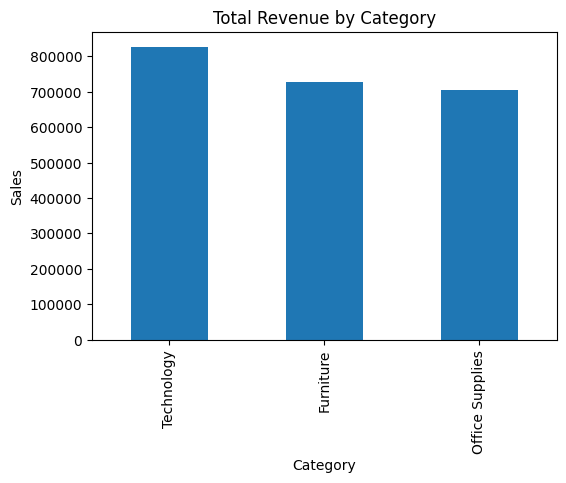

In [13]:
#Bar plot:
category_sales.plot(kind='bar', figsize=(6,4))
plt.title("Total Revenue by Category")
plt.ylabel("Sales")
plt.show()

# Task 1.2 — Region with Most Consistent Growth

In [14]:
region_year_sales = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
region_year_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


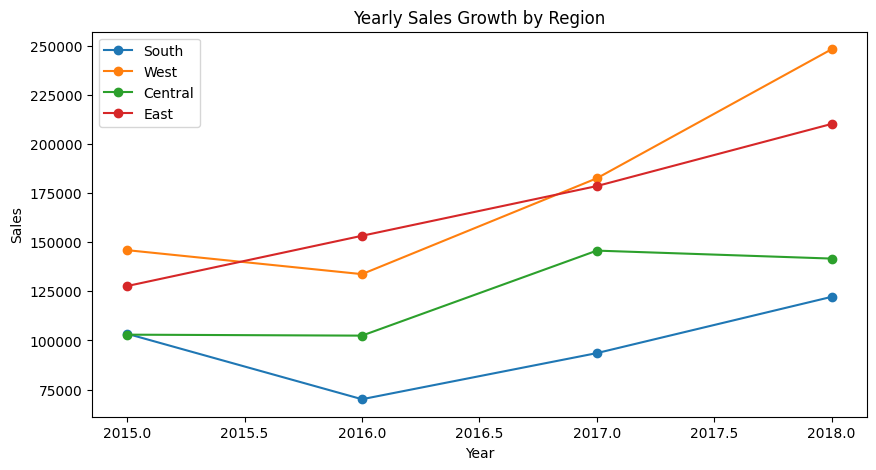

In [15]:
plt.figure(figsize=(10,5))

for region in df['Region'].unique():
    temp = region_year_sales[region_year_sales['Region'] == region]
    plt.plot(temp['Year'], temp['Sales'], marker='o', label=region)

plt.legend()
plt.title("Yearly Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

# Task 1.3 — Average Shipping Time

In [16]:
#Create shipping days:
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [17]:
#Average:
df['Shipping_Days'].mean()

np.float64(3.9611224489795918)

In [18]:
#By region:
shipping_region = df.groupby('Region')['Shipping_Days'].mean()
print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping_Days, dtype: float64


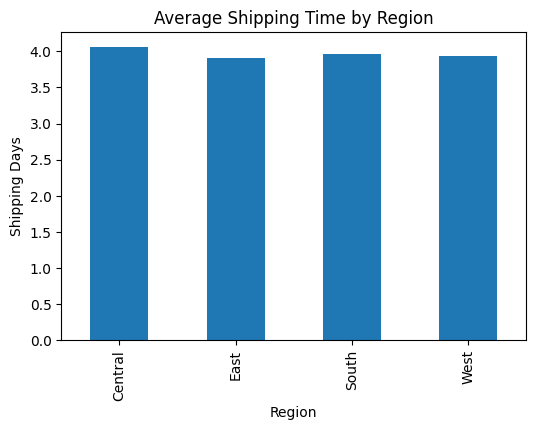

In [19]:
#Plot:
shipping_region.plot(kind='bar', figsize=(6,4))
plt.title("Average Shipping Time by Region")
plt.ylabel("Shipping Days")
plt.show()

# Task 1.4 — Seasonality (Monthly Spike)

In [20]:
#Monthly sales by year:
monthly_year = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_year.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


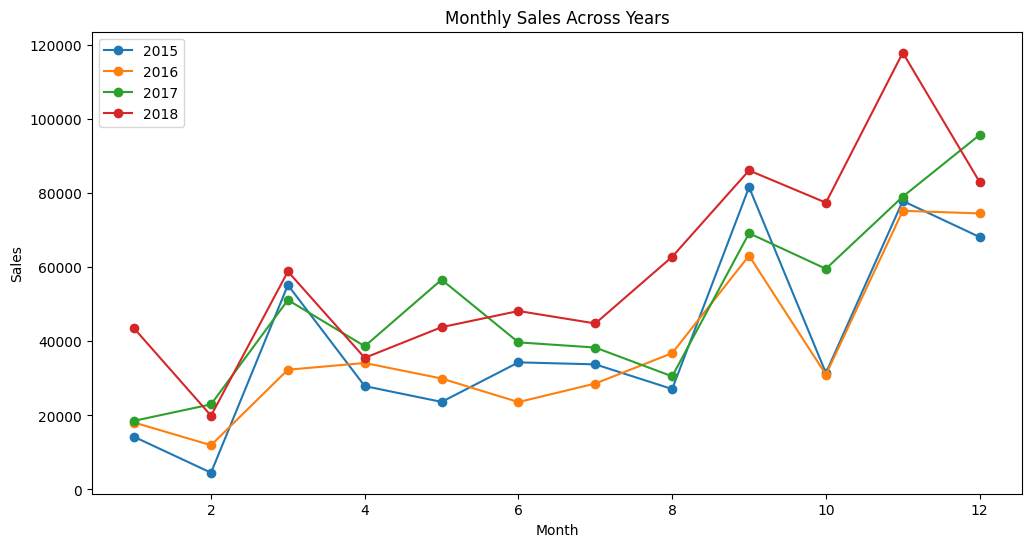

In [21]:
#Plot:
plt.figure(figsize=(12,6))

for year in monthly_year['Year'].unique():
    temp = monthly_year[monthly_year['Year'] == year]
    plt.plot(temp['Month'], temp['Sales'], marker='o', label=year)

plt.legend()
plt.title("Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# **Task 2 :- Time Series Analysis & Decomposition**

# Plot Monthly Sales Trend

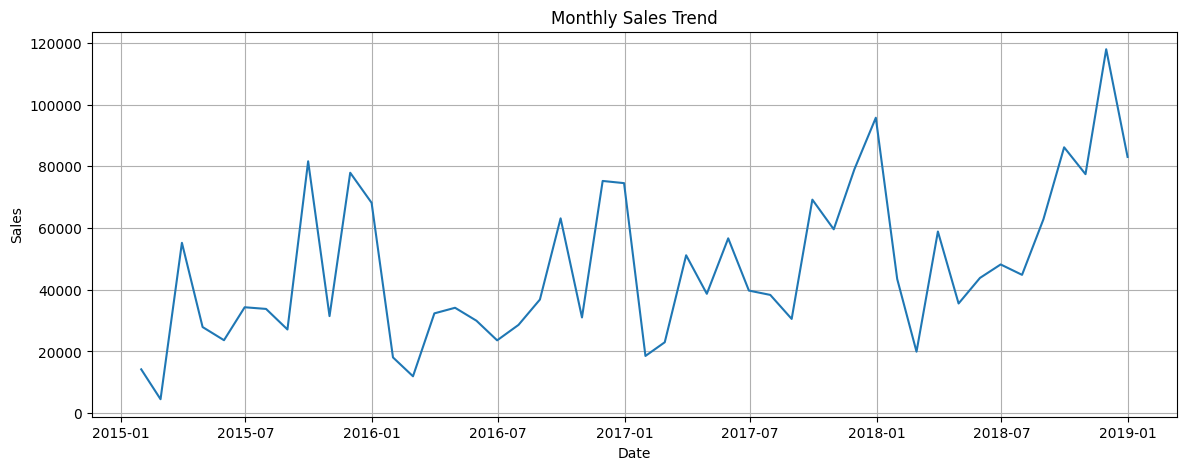

In [22]:

plt.figure(figsize=(14,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()
plt.show()

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Time Series Decomposition

In [24]:
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

In [25]:
#Extract components:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot all 4 components clearly on one figure

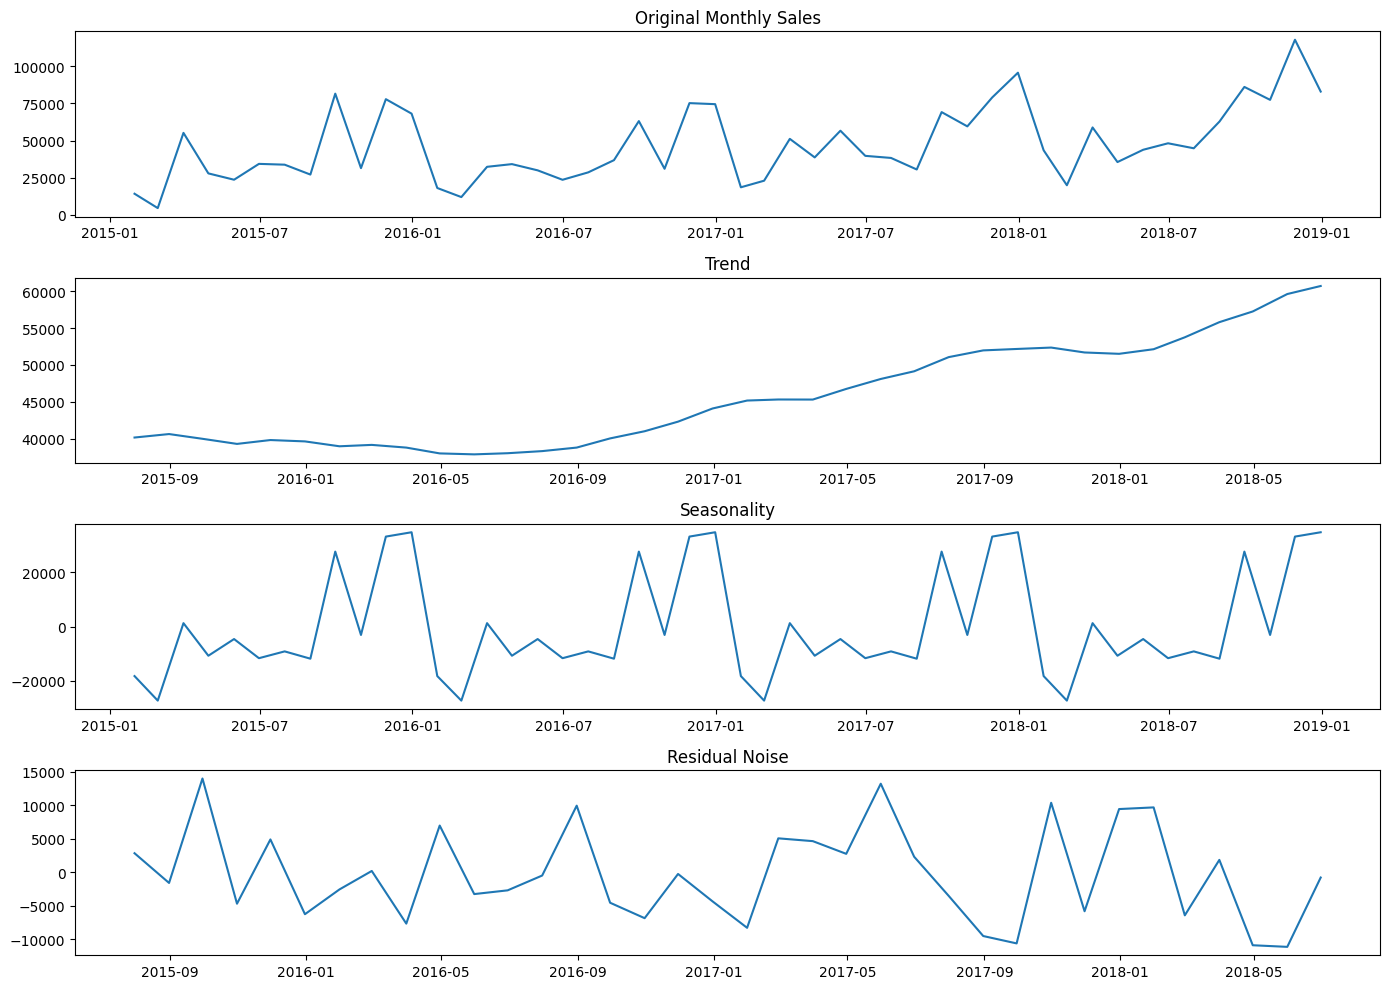

In [26]:
plt.figure(figsize=(14,10))

plt.subplot(4,1,1)
plt.plot(monthly_sales)
plt.title("Original Monthly Sales")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonality")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual Noise")

plt.tight_layout()
plt.show()

**Observations :-**

-> Sales trend shows overall upward growth over 4 years.

-> Strong seasonality appears, suggesting certain months repeatedly perform better.

-> Residual spikes indicate unusual events such as festive sales.

-> End-of-year months often show increased demand.

# ADF Test (Stationarity Check)

In [27]:
from statsmodels.tsa.stattools import adfuller

In [28]:
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
1% -3.5778480370438146
5% -2.925338105429433
10% -2.6007735310095064


**What is Stationarity?**

Ans:- A time series is stationary if its statistical properties such as mean and variance remain constant over time. Forecasting models like SARIMA usually require stationary data.


# Differencing (if non-stationary)

In [29]:
monthly_sales_diff = monthly_sales.diff().dropna()

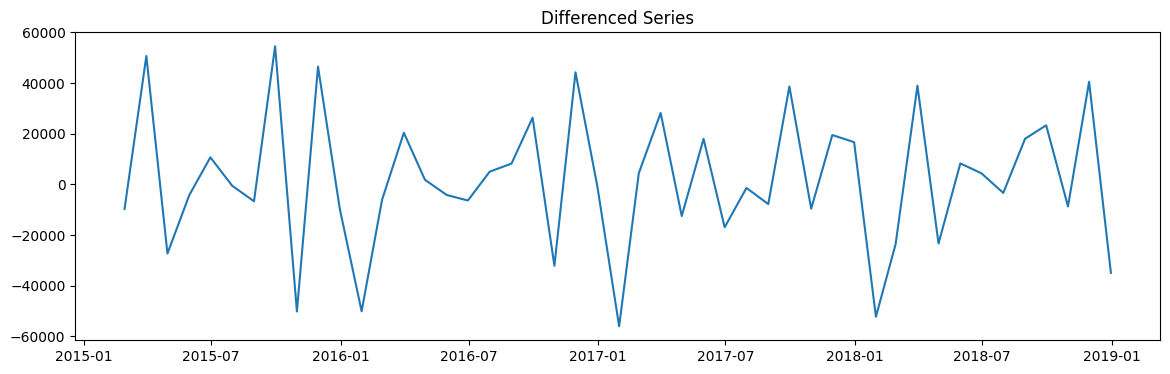

In [30]:
plt.figure(figsize=(14,4))
plt.plot(monthly_sales_diff)
plt.title("Differenced Series")
plt.show()

In [31]:
result2 = adfuller(monthly_sales_diff)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])

ADF Statistic: -8.727061830353268
p-value: 3.2669175472796045e-14


**Conclusion**

The Augmented Dickey-Fuller (ADF) test was performed to check stationarity of the monthly sales series. The p-value obtained was significantly lower than 0.05, so we reject the null hypothesis of non-stationarity. This indicates that the sales time series is stationary and suitable for forecasting models like SARIMA without mandatory differencing.

# **Task 3 :— Sales Forecasting**

# Model 1 — SARIMA (Statistical Model)

In [32]:
!pip install statsmodels

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

**Train/Test Split**

In [34]:

train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 45
Test size: 3


**Build SARIMA Model**

In [35]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12)
)


In [36]:
#Fit:
sarima_model = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [37]:
#Forecast Next 3 Months
forecast = sarima_model.forecast(steps=3)
forecast

,predicted_mean
2018-10-31,61804.241434
2018-11-30,89627.926347
2018-12-31,99902.353510


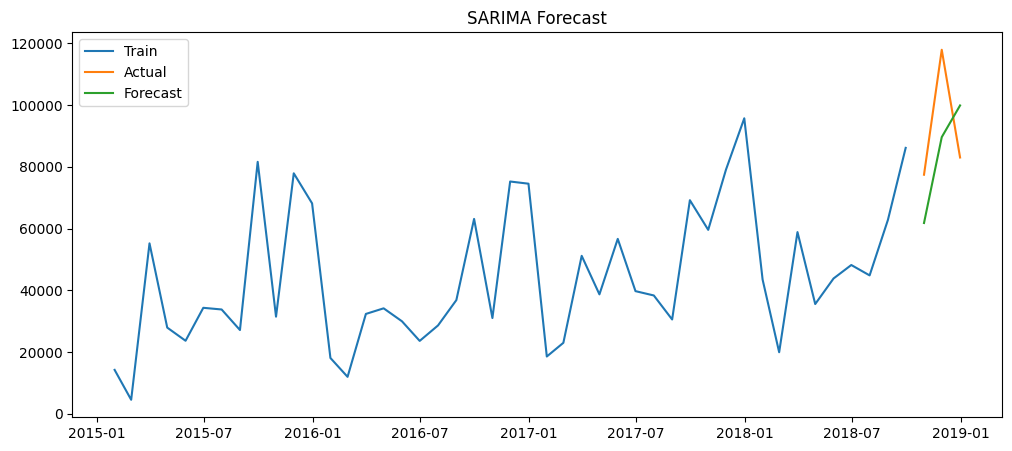

In [38]:
#Plot Actual vs Predicted
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title("SARIMA Forecast")
plt.show()

## Evaluate Model

In [39]:
#MAE:
mae = mean_absolute_error(test, forecast)
print("MAE:", mae)


MAE: 20275.36104327607


In [40]:
#RMSE
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)


RMSE: 21062.316480678182


In [41]:
#MAPE
mape = np.mean(np.abs((test - forecast) / test)) * 100
print("MAPE:", mape)

MAPE: 21.507903864352564


In [42]:
pred = sarima_model.get_forecast(steps=3)

forecast = pred.predicted_mean
conf_int = pred.conf_int()

print(forecast)
print(conf_int)

2018-10-31    61804.241434
2018-11-30    89627.926347
2018-12-31    99902.353510
Freq: ME, Name: predicted_mean, dtype: float64
             lower Sales    upper Sales
2018-10-31  37174.875302   86433.607565
2018-11-30  64998.258248  114257.594446
2018-12-31  75272.383670  124532.323351


##Model 2: Prophet

In [43]:
!pip install prophet

In [44]:
from prophet import Prophet

In [45]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [46]:
#Train/Test Split
train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]


In [47]:
#Train Prophet Model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)


In [48]:
#Future Forecast (3 Months)
future = model.make_future_dataframe(periods=3, freq='M')
forecast = model.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [49]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558193,39015.208104,55567.876327
44,2018-09-30,86613.953271,79201.532568,94955.730446
45,2018-10-31,51318.943812,43438.666437,59605.223848
46,2018-11-30,90325.654736,81657.448834,98819.865665
47,2018-12-31,90041.084430,81914.344347,98364.116506


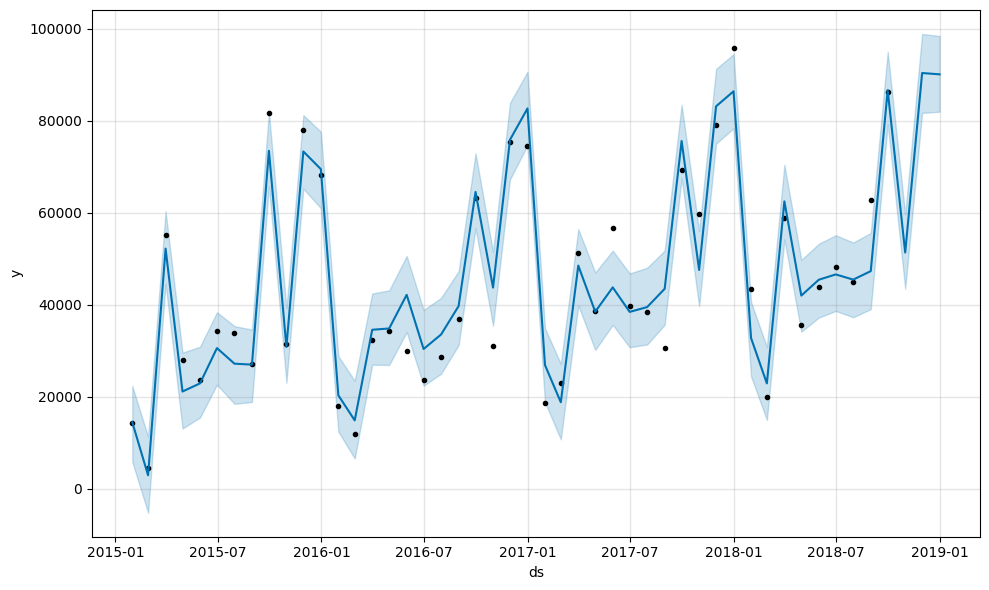

In [50]:
#Plot Forecast
fig = model.plot(forecast)

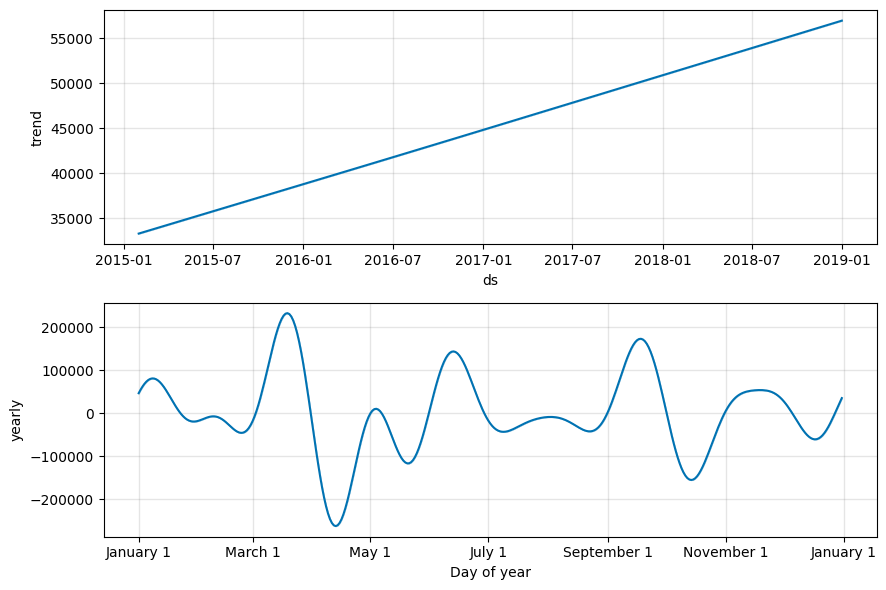

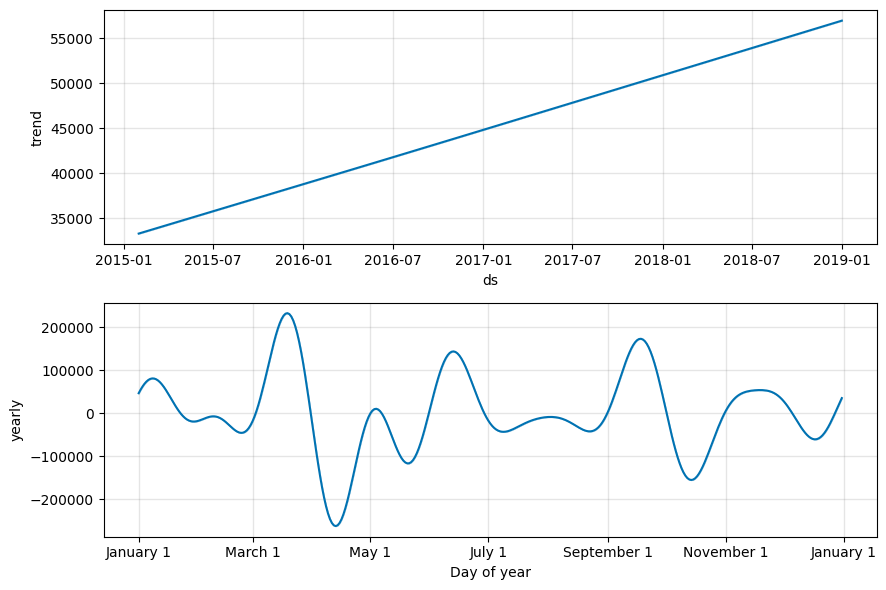

In [51]:
#Seasonality Plot
model.plot_components(forecast)

In [52]:
#Evaluate Prophet
pred_prophet = forecast['yhat'].tail(3).values
actual = test_prophet['y'].values

In [53]:
#MAE:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_prophet = mean_absolute_error(actual, pred_prophet)
print("MAE:", mae_prophet)

MAE: 20250.794427610937


In [54]:
#RMSE:
rmse_prophet = np.sqrt(mean_squared_error(actual, pred_prophet))
print("RMSE:", rmse_prophet)

RMSE: 22318.41136551923


In [55]:
#MAPE:
mape_prophet = np.mean(np.abs((actual - pred_prophet) / actual)) * 100
print("MAPE:", mape_prophet)

MAPE: 21.864628287701436


# **Model 3: XGBoost**

In [56]:
!pip install xgboost

In [57]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [58]:
#Create Feature DataFrame
sales_df = monthly_sales.reset_index()
sales_df.columns = ['Date', 'Sales']
sales_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [59]:
#Create Lag Features
sales_df['lag1'] = sales_df['Sales'].shift(1)
sales_df['lag2'] = sales_df['Sales'].shift(2)
sales_df['lag3'] = sales_df['Sales'].shift(3)

sales_df['rolling_mean'] = sales_df['Sales'].rolling(3).mean()

In [60]:
#Date features:
sales_df['month'] = sales_df['Date'].dt.month
sales_df['quarter'] = sales_df['Date'].dt.quarter

In [61]:
#Season:
def season(month):
    if month in [12,1,2]:
        return 1
    elif month in [3,4,5]:
        return 2
    elif month in [6,7,8]:
        return 3
    else:
        return 4

sales_df['season'] = sales_df['month'].apply(season)

In [62]:
#Drop NaNs:
sales_df = sales_df.dropna()
sales_df.head()

,Date,Sales,lag1,lag2,lag3,rolling_mean,month,quarter,season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [63]:
#Split Features and Target
X = sales_df[['lag1','lag2','lag3','rolling_mean','month','quarter','season']]
y = sales_df['Sales']

In [64]:
#Train/Test:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [65]:
#Train XGBoost
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
#Predict
pred_xgb = model.predict(X_test)
pred_xgb

array([86465.82, 86506.77, 84327.28], dtype=float32)

**Evaluate**

In [67]:
#MAE:
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print("MAE:", mae_xgb)


MAE: 13915.321041666664


In [68]:
#RMSE:
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print("RMSE:", rmse_xgb)

RMSE: 18893.847269098238


In [69]:
#MAPE:
mape_xgb = np.mean(np.abs((y_test - pred_xgb) / y_test)) * 100
print("MAPE:", mape_xgb)


MAPE: 13.285400568532047


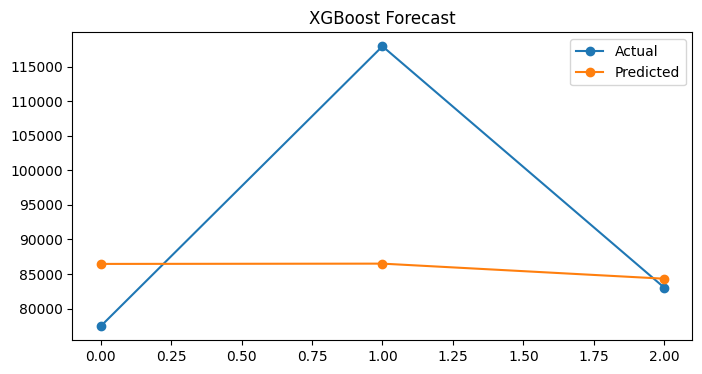

In [70]:
#Plot Actual vs Predicted
plt.figure(figsize=(8,4))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(pred_xgb, label='Predicted', marker='o')
plt.legend()
plt.title("XGBoost Forecast")
plt.show()

| Model   |           MAE |          RMSE |       MAPE |
| ------- | ------------: | ------------: | ---------: |
| SARIMA  |     20,275.36 |     21,062.32 |     21.51% |
| Prophet |     20,250.79 |     22,318.41 |     21.86% |
| XGBoost | **13,915.32** | **18,893.85** | **13.29%** |


# Explanation
Three forecasting approaches were evaluated: SARIMA, Prophet, and XGBoost. XGBoost achieved the best performance across all evaluation metrics, with the lowest MAE (13,915.32), lowest RMSE (18,893.85), and lowest MAPE (13.29%). This indicates that XGBoost captured nonlinear patterns and feature interactions more effectively than traditional time-series models. Therefore, XGBoost is selected as the production model for category-level and region-level forecasting.

# **Task 4 :— Product Category & Region Level Forecasting**

In [71]:
#Create Filtered Data
furniture_df = df[df['Category'] == 'Furniture']
technology_df = df[df['Category'] == 'Technology']
office_df = df[df['Category'] == 'Office Supplies']

west_df = df[df['Region'] == 'West']
east_df = df[df['Region'] == 'East']


In [72]:
#Convert Each to Monthly Sales
def monthly_segment_sales(segment_df):
    monthly = segment_df.resample('M', on='Order Date')['Sales'].sum().reset_index()
    monthly.columns = ['Date', 'Sales']
    return monthly

In [73]:
#Create monthly datasets:
furniture_monthly = monthly_segment_sales(furniture_df)
technology_monthly = monthly_segment_sales(technology_df)
office_monthly = monthly_segment_sales(office_df)
west_monthly = monthly_segment_sales(west_df)
east_monthly = monthly_segment_sales(east_df)

/tmp/ipykernel_637/191550814.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = segment_df.resample('M', on='Order Date')['Sales'].sum().reset_index()
/tmp/ipykernel_637/191550814.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = segment_df.resample('M', on='Order Date')['Sales'].sum().reset_index()
/tmp/ipykernel_637/191550814.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = segment_df.resample('M', on='Order Date')['Sales'].sum().reset_index()
/tmp/ipykernel_637/191550814.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = segment_df.resample('M', on='Order Date')['Sales'].sum().reset_index()
/tmp/ipykernel_637/191550814.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead

In [74]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

In [75]:
def forecast_xgboost(segment_df):

    data = segment_df.copy()

    # Lag features
    data['lag1'] = data['Sales'].shift(1)
    data['lag2'] = data['Sales'].shift(2)
    data['lag3'] = data['Sales'].shift(3)

    # Rolling mean
    data['rolling_mean'] = data['Sales'].rolling(3).mean()

    # Date features
    data['month'] = data['Date'].dt.month
    data['quarter'] = data['Date'].dt.quarter

    # Season
    def season(month):
        if month in [12,1,2]:
            return 1
        elif month in [3,4,5]:
            return 2
        elif month in [6,7,8]:
            return 3
        else:
            return 4

    data['season'] = data['month'].apply(season)

    data = data.dropna()

    X = data[['lag1','lag2','lag3','rolling_mean','month','quarter','season']]
    y = data['Sales']

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    )

    model.fit(X, y)

    forecasts = []

    last_data = data.iloc[-1:].copy()

    for i in range(3):
        X_pred = last_data[['lag1','lag2','lag3','rolling_mean','month','quarter','season']]
        pred = model.predict(X_pred)[0]
        forecasts.append(pred)

        new_row = last_data.copy()
        new_row['lag3'] = new_row['lag2']
        new_row['lag2'] = new_row['lag1']
        new_row['lag1'] = pred
        new_row['rolling_mean'] = (
            new_row['lag1'] + new_row['lag2'] + new_row['lag3']
        ) / 3

        new_row['month'] += 1
        if new_row['month'].values[0] > 12:
            new_row['month'] = 1

        new_row['quarter'] = ((new_row['month'] - 1) // 3) + 1
        new_row['season'] = new_row['month'].apply(season)

        last_data = new_row

    return forecasts

In [76]:
#Generate Forecasts
furniture_forecast = forecast_xgboost(furniture_monthly)
technology_forecast = forecast_xgboost(technology_monthly)
office_forecast = forecast_xgboost(office_monthly)
west_forecast = forecast_xgboost(west_monthly)
east_forecast = forecast_xgboost(east_monthly)

In [77]:
#Check:
print("Furniture:", furniture_forecast)
print("Technology:", technology_forecast)
print("Office Supplies:", office_forecast)
print("West:", west_forecast)
print("East:", east_forecast)

Furniture: [np.float32(31425.168), np.float32(9716.003), np.float32(6214.6865)]
Technology: [np.float32(21819.178), np.float32(20182.088), np.float32(24370.316)]
Office Supplies: [np.float32(29633.475), np.float32(25796.031), np.float32(25957.26)]
West: [np.float32(29677.768), np.float32(11175.512), np.float32(15125.339)]
East: [np.float32(19581.693), np.float32(25088.459), np.float32(25353.447)]


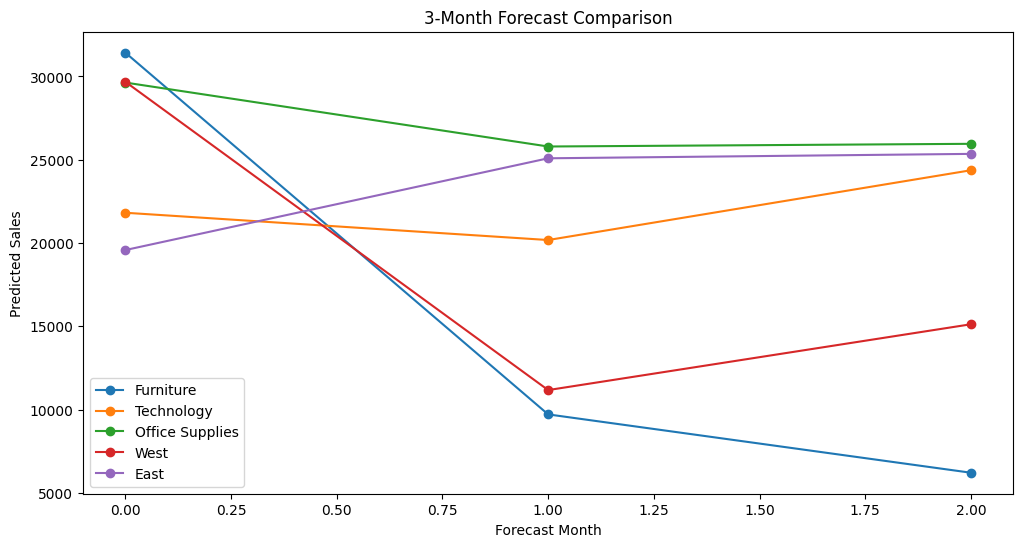

In [78]:
#Plot All Forecasts Together
plt.figure(figsize=(12,6))

plt.plot(furniture_forecast, marker='o', label='Furniture')
plt.plot(technology_forecast, marker='o', label='Technology')
plt.plot(office_forecast, marker='o', label='Office Supplies')
plt.plot(west_forecast, marker='o', label='West')
plt.plot(east_forecast, marker='o', label='East')

plt.legend()
plt.title("3-Month Forecast Comparison")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.show()

**Q. Which category/region is showing strongest upcoming growth?**

Ans: Based on the XGBoost forecasting results, the Technology category shows the strongest upcoming category-level growth, indicating increasing customer demand for technology-related products. Among regions, the East region demonstrates the strongest growth, with predicted sales increasing consistently over the 3-month forecast horizon. This suggests that inventory allocation and supply chain focus should be increased for the East region and Technology products.

# **Task 5 :— Anomaly Detection**

In [79]:
#Prepare Weekly Sales
weekly_sales = df.resample('W', on='Order Date')['Sales'].sum().reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [80]:
#Isolation Forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales['anomaly'] = iso.fit_predict(weekly_sales[['Sales']])

In [81]:
anomalies = weekly_sales[weekly_sales['anomaly'] == -1]
anomalies

,Order Date,Sales,anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


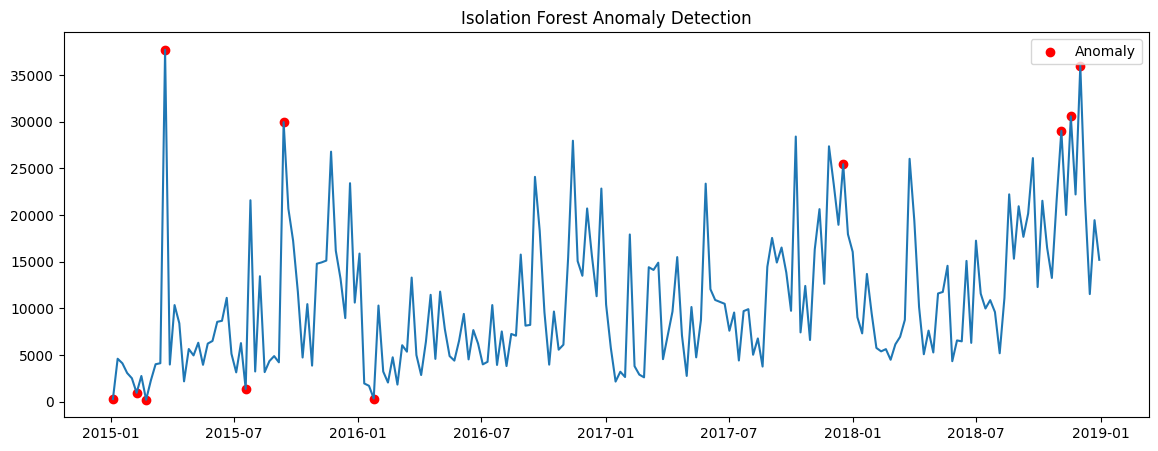

In [82]:
#Plot Isolation Forest Anomalies
plt.figure(figsize=(14,5))
plt.plot(weekly_sales['Order Date'], weekly_sales['Sales'])

plt.scatter(
    anomalies['Order Date'],
    anomalies['Sales'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("Isolation Forest Anomaly Detection")
plt.show()

In [83]:
#Z-Score Method
rolling_mean = weekly_sales['Sales'].rolling(4).mean()
rolling_std = weekly_sales['Sales'].rolling(4).std()

In [84]:
#Z-score:
weekly_sales['z_score'] = (
    weekly_sales['Sales'] - rolling_mean
) / rolling_std

In [85]:
#Flag anomalies:
z_anomalies = weekly_sales[
    abs(weekly_sales['z_score']) > 2
]

z_anomalies

,Order Date,Sales,anomaly,z_score


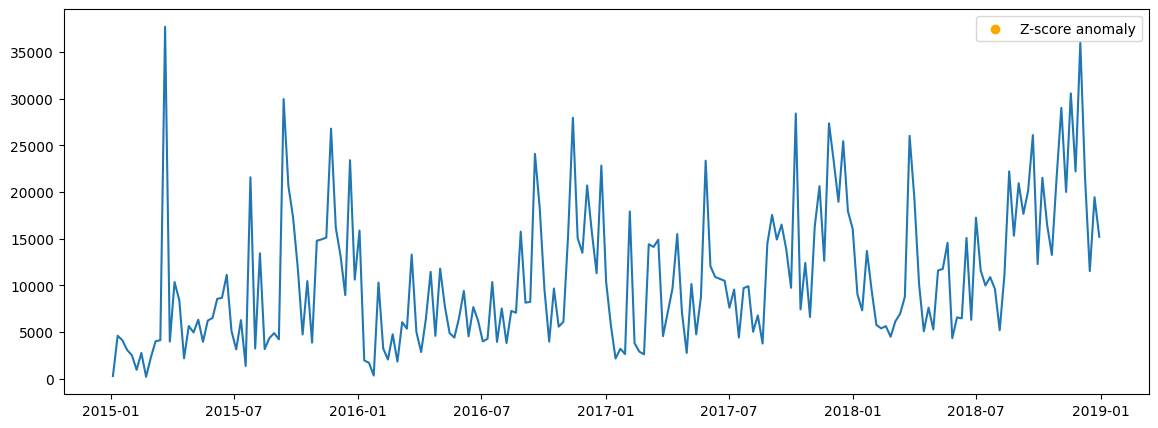

In [86]:
#Plot Z-score Anomalies
plt.figure(figsize=(14,5))
plt.plot(weekly_sales['Order Date'], weekly_sales['Sales'])

plt.scatter(
    z_anomalies['Order Date'],
    z_anomalies['Sales'],
    color='orange',
    label='Z-score anomaly'
)

plt.legend()
plt.show()

In [87]:
print("Isolation Forest anomalies:", len(anomalies))
print("Z-score anomalies:", len(z_anomalies))

Isolation Forest anomalies: 11
Z-score anomalies: 0


**Q. Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?**

Ans: Isolation Forest detected 11 anomalous sales weeks, while the Z-score based method detected no anomalies using the chosen threshold of 2 standard deviations. This suggests that the sales data contains complex non-linear patterns that are better captured by machine learning-based anomaly detection methods than simple statistical thresholding. Isolation Forest proved more effective in identifying unusual sales spikes and drops.

# **Task 6 :- Product Demand Segmentation using Clustering**

**Aggregate Product Features**

In [88]:
#Run:
subcat_features = df.groupby('Sub-Category').agg({
    'Sales': ['sum', 'mean', 'std']
})

In [89]:
#Flatten columns:
subcat_features.columns = [
    'total_sales',
    'avg_order_value',
    'sales_volatility'
]

subcat_features = subcat_features.reset_index()
subcat_features.head()

,Sub-Category,total_sales,avg_order_value,sales_volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


**Growth Rate Feature**

In [90]:
#Yearly sales by subcategory
growth = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()

In [91]:
#Compute growth:
growth_rate = growth.groupby('Sub-Category')['Sales'].pct_change()
growth['growth_rate'] = growth_rate

In [92]:
#Average growth:
avg_growth = growth.groupby('Sub-Category')['growth_rate'].mean().reset_index()

In [93]:
#Merge:
subcat_features = subcat_features.merge(
    avg_growth,
    on='Sub-Category',
    how='left'
)

subcat_features = subcat_features.fillna(0)
subcat_features.head()

,Sub-Category,total_sales,avg_order_value,sales_volatility,growth_rate
0,Accessories,164186.7000,217.178175,337.723800,0.376381
1,Appliances,104618.4030,227.926804,378.006735,0.399276
2,Art,26705.4100,34.019631,60.301752,0.166056
3,Binders,200028.7850,134.067550,568.099970,0.218736
4,Bookcases,113813.1987,503.598224,641.419280,0.238065


**Scale Features**

In [94]:
from sklearn.preprocessing import StandardScaler

features = subcat_features[
    ['total_sales', 'avg_order_value', 'sales_volatility', 'growth_rate']
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

**Elbow Method**

In [95]:
from sklearn.cluster import KMeans

In [96]:
inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

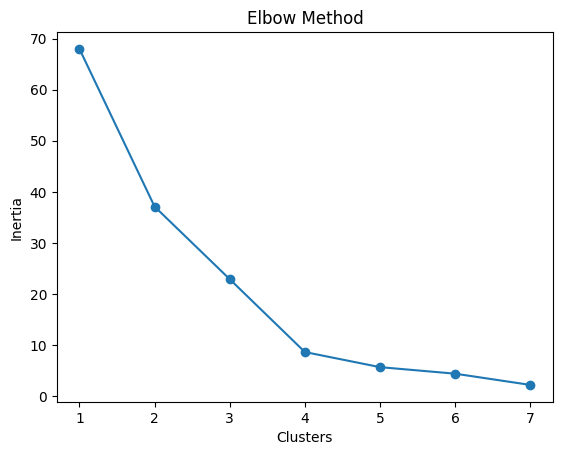

In [97]:
#Plot:
plt.plot(range(1,8), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


**Apply KMeans**

In [98]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

subcat_features['Cluster'] = clusters

**View Clusters**

In [99]:
subcat_features[['Sub-Category', 'Cluster']]

,Sub-Category,Cluster
0,Accessories,2
1,Appliances,1
2,Art,1
3,Binders,2
4,Bookcases,1
5,Chairs,2
6,Copiers,0
7,Envelopes,1
8,Fasteners,1
9,Furnishings,1


**PCA Visualization**

In [100]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

In [101]:
#Add to dataframe:
subcat_features['PCA1'] = pca_result[:, 0]
subcat_features['PCA2'] = pca_result[:, 1]

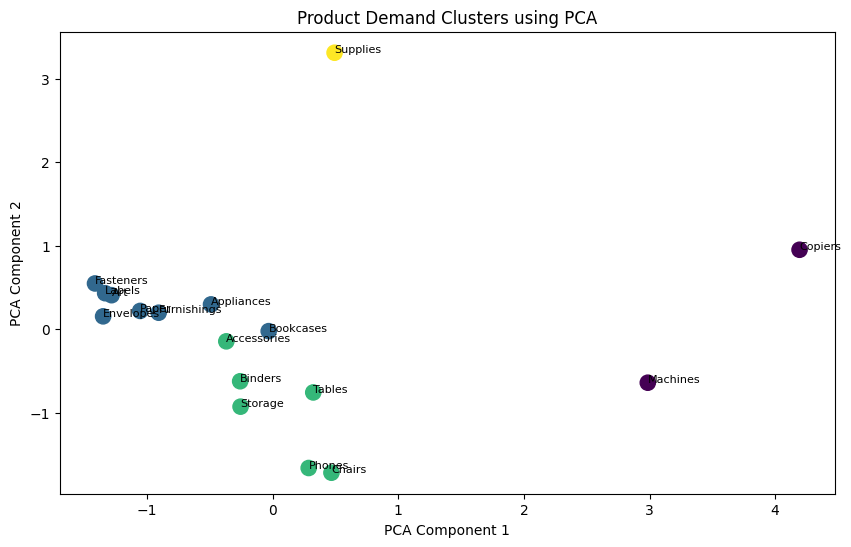

In [102]:
#Plot clusters:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    subcat_features['PCA1'],
    subcat_features['PCA2'],
    c=subcat_features['Cluster'],
    s=120
)

for i, txt in enumerate(subcat_features['Sub-Category']):
    plt.annotate(
        txt,
        (subcat_features['PCA1'][i], subcat_features['PCA2'][i]),
        fontsize=8
    )

plt.title("Product Demand Clusters using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

K-Means clustering with 4 clusters successfully segmented product sub-categories into distinct demand groups. Cluster analysis revealed premium high-value products, stable low-volume products, high-volume frequently purchased products, and highly volatile niche products. These insights can improve inventory planning and stocking strategy.

# **Task 7 :- Streamlit Dashboard**